
DataFrame de Resumen (listo para plotear):
    model primary     energy     theta_range detector        A1    A1_err  \
0  SIB23e   Helio  17.5-18.0   [0.0°, 21.8°]      UMD -0.001456  0.001320   
1  SIB23e   Helio  17.5-18.0   [0.0°, 21.8°]       SD -0.001444  0.000761   
2  SIB23e   Helio  17.5-18.0  [21.8°, 31.6°]      UMD -0.000014  0.001364   
3  SIB23e   Helio  17.5-18.0  [21.8°, 31.6°]       SD  0.000489  0.000674   
4  SIB23e   Helio  17.5-18.0  [31.6°, 40.0°]      UMD -0.002015  0.001407   

   sin2_theta_mid                          label  
0        0.068957  SIB23e - Helio (17.5-18.0 eV)  
1        0.068957  SIB23e - Helio (17.5-18.0 eV)  
2        0.206238  SIB23e - Helio (17.5-18.0 eV)  
3        0.206238  SIB23e - Helio (17.5-18.0 eV)  
4        0.343869  SIB23e - Helio (17.5-18.0 eV)  


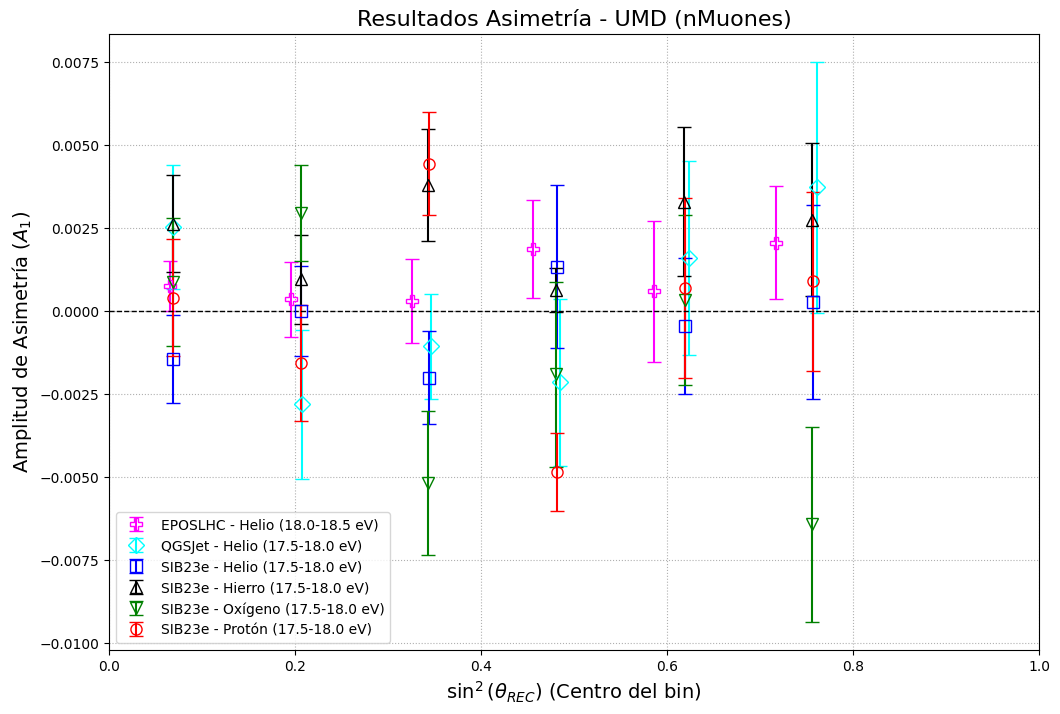

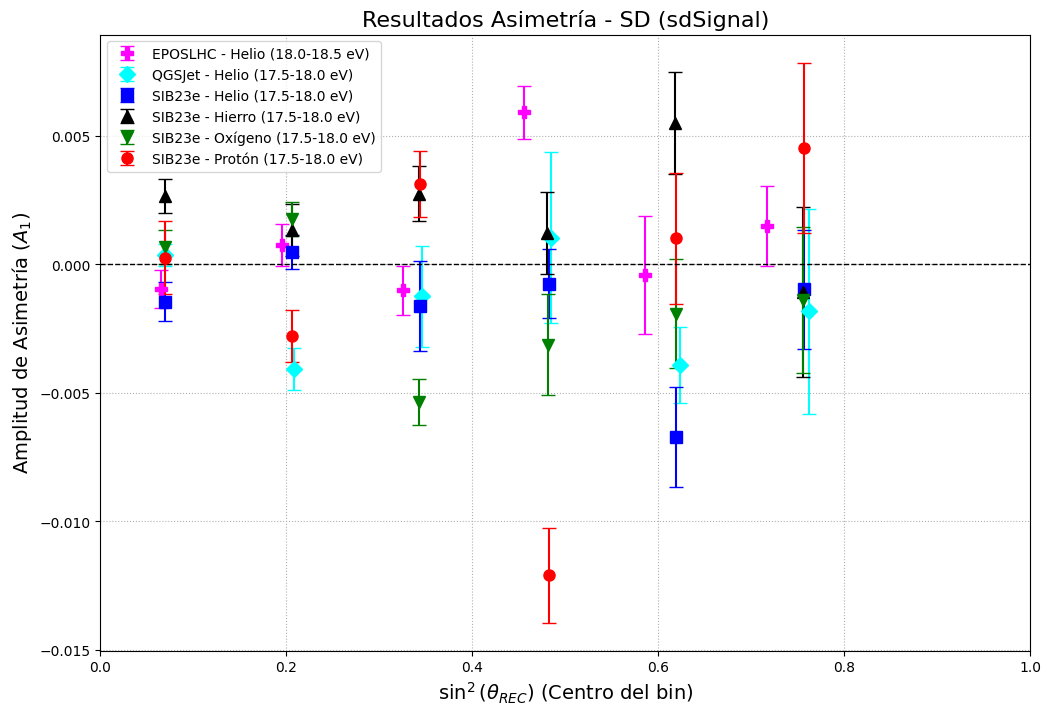

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Cargar los Datos de Resumen (Extraídos de tus 6 PDFs) ---
# (En el futuro, podrías modificar tu script 'generar_reporte.py' 
#  para que guarde esta tabla como un .csv y así cargarla 
#  automáticamente, pero por ahora, los cargo manualmente)

data = [
    # SIB23e - Helio @ 17.5-18.0 (de Reporte_parquet_sib_helio_17_v3.pdf)
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'UMD', 'A1': -0.001456, 'A1_err': 0.001320},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'SD', 'A1': -0.001444, 'A1_err': 0.000761},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'UMD', 'A1': -0.000014, 'A1_err': 0.001364},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'SD', 'A1': 0.000489, 'A1_err': 0.000674},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 40.0°]', 'detector': 'UMD', 'A1': -0.002015, 'A1_err': 0.001407},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 40.0°]', 'detector': 'SD', 'A1': -0.001614, 'A1_err': 0.001736},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[40.0°, 47.9°]', 'detector': 'UMD', 'A1': 0.001331, 'A1_err': 0.002464},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[40.0°, 47.9°]', 'detector': 'SD', 'A1': -0.000754, 'A1_err': 0.001335},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'UMD', 'A1': -0.000462, 'A1_err': 0.002048},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'SD', 'A1': -0.006703, 'A1_err': 0.001947},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.3°]', 'detector': 'UMD', 'A1': 0.000262, 'A1_err': 0.002925},
    {'model': 'SIB23e', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.3°]', 'detector': 'SD', 'A1': -0.000971, 'A1_err': 0.002301},

    # SIB23e - Protón @ 17.5-18.0 (de Reporte_parquet_sib_proton_17_v3.pdf)
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'UMD', 'A1': 0.000398, 'A1_err': 0.001749},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'SD', 'A1': 0.000262, 'A1_err': 0.001419},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'UMD', 'A1': -0.001577, 'A1_err': 0.001754},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'SD', 'A1': -0.002777, 'A1_err': 0.001022},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 40.0°]', 'detector': 'UMD', 'A1': 0.004427, 'A1_err': 0.001557},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 40.0°]', 'detector': 'SD', 'A1': 0.003125, 'A1_err': 0.001277},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[40.0°, 47.9°]', 'detector': 'UMD', 'A1': -0.004860, 'A1_err': 0.001170},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[40.0°, 47.9°]', 'detector': 'SD', 'A1': -0.012102, 'A1_err': 0.001833},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'UMD', 'A1': 0.000686, 'A1_err': 0.002712},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'SD', 'A1': 0.001019, 'A1_err': 0.002543},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.3°]', 'detector': 'UMD', 'A1': 0.000883, 'A1_err': 0.002688},
    {'model': 'SIB23e', 'primary': 'Protón', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.3°]', 'detector': 'SD', 'A1': 0.004539, 'A1_err': 0.003318},

    # SIB23e - Oxígeno @ 17.5-18.0 (de Reporte_parquet_sib_oxigeno_17_v3.pdf)
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'UMD', 'A1': 0.000873, 'A1_err': 0.001923},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'SD', 'A1': 0.000686, 'A1_err': 0.000664},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'UMD', 'A1': 0.002935, 'A1_err': 0.001445},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'SD', 'A1': 0.001753, 'A1_err': 0.000664},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 39.9°]', 'detector': 'UMD', 'A1': -0.005193, 'A1_err': 0.002164},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 39.9°]', 'detector': 'SD', 'A1': -0.005359, 'A1_err': 0.000883},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[39.9°, 47.9°]', 'detector': 'UMD', 'A1': -0.001917, 'A1_err': 0.002789},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[39.9°, 47.9°]', 'detector': 'SD', 'A1': -0.003119, 'A1_err': 0.001961},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'UMD', 'A1': 0.000322, 'A1_err': 0.002555},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[47.9°, 56.0°]', 'detector': 'SD', 'A1': -0.001914, 'A1_err': 0.002112},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.2°]', 'detector': 'UMD', 'A1': -0.006439, 'A1_err': 0.002925},
    {'model': 'SIB23e', 'primary': 'Oxígeno', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.2°]', 'detector': 'SD', 'A1': -0.001380, 'A1_err': 0.002843},

    # SIB23e - Hierro @ 17.5-18.0 (de Reporte_parquet_sib_hierro_17_v3.pdf)
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'UMD', 'A1': 0.002621, 'A1_err': 0.001465},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'SD', 'A1': 0.002662, 'A1_err': 0.000680},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'UMD', 'A1': 0.000943, 'A1_err': 0.001331},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.6°]', 'detector': 'SD', 'A1': 0.001351, 'A1_err': 0.001006},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 39.9°]', 'detector': 'UMD', 'A1': 0.003784, 'A1_err': 0.001685},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[31.6°, 39.9°]', 'detector': 'SD', 'A1': 0.002760, 'A1_err': 0.001060},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[39.9°, 47.8°]', 'detector': 'UMD', 'A1': 0.000626, 'A1_err': 0.000676},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[39.9°, 47.8°]', 'detector': 'SD', 'A1': 0.001211, 'A1_err': 0.001589},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[47.8°, 56.0°]', 'detector': 'UMD', 'A1': 0.003289, 'A1_err': 0.002238},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[47.8°, 56.0°]', 'detector': 'SD', 'A1': 0.005502, 'A1_err': 0.001991},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.2°]', 'detector': 'UMD', 'A1': 0.002748, 'A1_err': 0.002302},
    {'model': 'SIB23e', 'primary': 'Hierro', 'energy': '17.5-18.0', 'theta_range': '[56.0°, 65.2°]', 'detector': 'SD', 'A1': -0.001071, 'A1_err': 0.003315},

    # QGSJet - Helio @ 17.5-18.0 (de Reporte_parquet_qgs_helium_17_v3.pdf)
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'UMD', 'A1': 0.002525, 'A1_err': 0.001881},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[0.0°, 21.8°]', 'detector': 'SD', 'A1': 0.000361, 'A1_err': 0.000429},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.8°]', 'detector': 'UMD', 'A1': -0.002822, 'A1_err': 0.002256},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[21.8°, 31.8°]', 'detector': 'SD', 'A1': -0.004070, 'A1_err': 0.000802},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[31.8°, 40.1°]', 'detector': 'UMD', 'A1': -0.001073, 'A1_err': 0.001582},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[31.8°, 40.1°]', 'detector': 'SD', 'A1': -0.001233, 'A1_err': 0.001968},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[40.1°, 48.1°]', 'detector': 'UMD', 'A1': -0.002153, 'A1_err': 0.002510},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[40.1°, 48.1°]', 'detector': 'SD', 'A1': 0.001046, 'A1_err': 0.003338},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[48.1°, 56.3°]', 'detector': 'UMD', 'A1': 0.001587, 'A1_err': 0.002931},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[48.1°, 56.3°]', 'detector': 'SD', 'A1': -0.003909, 'A1_err': 0.001489},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[56.3°, 65.7°]', 'detector': 'UMD', 'A1': 0.003715, 'A1_err': 0.003794},
    {'model': 'QGSJet', 'primary': 'Helio', 'energy': '17.5-18.0', 'theta_range': '[56.3°, 65.7°]', 'detector': 'SD', 'A1': -0.001829, 'A1_err': 0.003999},

    # EPOSLHC - Helio @ 18.0-18.5 (de Reporte_parquet_epos_helio_18_v3.pdf)
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[0.0°, 21.2°]', 'detector': 'UMD', 'A1': 0.000748, 'A1_err': 0.000764},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[0.0°, 21.2°]', 'detector': 'SD', 'A1': -0.000956, 'A1_err': 0.000725},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[21.2°, 30.7°]', 'detector': 'UMD', 'A1': 0.000340, 'A1_err': 0.001132},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[21.2°, 30.7°]', 'detector': 'SD', 'A1': 0.000740, 'A1_err': 0.000820},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[30.7°, 38.7°]', 'detector': 'UMD', 'A1': 0.000300, 'A1_err': 0.001273},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[30.7°, 38.7°]', 'detector': 'SD', 'A1': -0.001005, 'A1_err': 0.000962},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[38.7°, 46.2°]', 'detector': 'UMD', 'A1': 0.001850, 'A1_err': 0.001476},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[38.7°, 46.2°]', 'detector': 'SD', 'A1': 0.005916, 'A1_err': 0.001029},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[46.2°, 53.8°]', 'detector': 'UMD', 'A1': 0.000587, 'A1_err': 0.002119},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[46.2°, 53.8°]', 'detector': 'SD', 'A1': -0.000411, 'A1_err': 0.002281},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[53.8°, 62.2°]', 'detector': 'UMD', 'A1': 0.002054, 'A1_err': 0.001692},
    {'model': 'EPOSLHC', 'primary': 'Helio', 'energy': '18.0-18.5', 'theta_range': '[53.8°, 62.2°]', 'detector': 'SD', 'A1': 0.001489, 'A1_err': 0.001562},
]

df_results = pd.DataFrame(data)

# --- 2. Ingeniería de Features para el Plot ---

def parse_theta_range_to_sin2(theta_range_str):
    """
    Toma un string '[38.7°, 46.2°]' y devuelve el valor 
    de sin^2(theta) en el punto medio del bin.
    """
    # Extraer los números
    matches = re.findall(r"(\d+\.\d+)", theta_range_str)
    if not matches:
        return np.nan
    
    th_min = float(matches[0])
    th_max = float(matches[1])
    
    # Calcular el punto medio en sin^2(theta)
    # Es más robusto promediar en sin^2 que en theta
    s2_min = np.sin(np.deg2rad(th_min))**2
    s2_max = np.sin(np.deg2rad(th_max))**2
    return (s2_min + s2_max) / 2.0

# Creamos la columna para el eje X
df_results['sin2_theta_mid'] = df_results['theta_range'].apply(parse_theta_range_to_sin2)

# Creamos una etiqueta única para cada serie
df_results['label'] = df_results['model'] + ' - ' + df_results['primary'] + ' (' + df_results['energy'] + ' eV)'

print("\nDataFrame de Resumen (listo para plotear):")
print(df_results.head())

# --- 3. Generar los "Money Plots" ---

# --- Plot 1: UMD (nMuones) ---
plt.figure(figsize=(12, 8))
ax_umd = plt.subplot(111)

# Diccionario para colores/marcadores
plot_styles = {
    'SIB23e - Protón (17.5-18.0 eV)': {'color': 'red', 'marker': 'o'},
    'SIB23e - Helio (17.5-18.0 eV)':  {'color': 'blue', 'marker': 's'},
    'SIB23e - Oxígeno (17.5-18.0 eV)': {'color': 'green', 'marker': 'v'},
    'SIB23e - Hierro (17.5-18.0 eV)':  {'color': 'black', 'marker': '^'},
    'QGSJet - Helio (17.5-18.0 eV)':  {'color': 'cyan', 'marker': 'D'},
    'EPOSLHC - Helio (18.0-18.5 eV)': {'color': 'magenta', 'marker': 'P'},
}

# Filtramos solo datos UMD
df_umd = df_results[df_results['detector'] == 'UMD']

for label, group in df_umd.groupby('label'):
    style = plot_styles.get(label, {'color': 'gray', 'marker': 'x'})
    ax_umd.errorbar(
        group['sin2_theta_mid'],
        group['A1'],
        yerr=group['A1_err'],
        label=label,
        fmt=style['marker'],
        color=style['color'],
        capsize=5,
        mfc='none', # Marcador hueco
        ms=8
    )

ax_umd.axhline(0, color='black', linestyle='--', linewidth=1)
ax_umd.set_xlabel(r"$\sin^2(\theta_{REC})$ (Centro del bin)", fontsize=14)
ax_umd.set_ylabel("Amplitud de Asimetría ($A_1$)", fontsize=14)
ax_umd.set_title("Resultados Asimetría - UMD (nMuones)", fontsize=16)
ax_umd.set_xlim(0, 1.0)
ax_umd.grid(True, linestyle=':')
ax_umd.legend()
plt.show()

# --- Plot 2: SD (sdSignal) ---
plt.figure(figsize=(12, 8))
ax_sd = plt.subplot(111)

# Filtramos solo datos SD
df_sd = df_results[df_results['detector'] == 'SD']

for label, group in df_sd.groupby('label'):
    style = plot_styles.get(label, {'color': 'gray', 'marker': 'x'})
    ax_sd.errorbar(
        group['sin2_theta_mid'],
        group['A1'],
        yerr=group['A1_err'],
        label=label,
        fmt=style['marker'],
        color=style['color'],
        capsize=5,
        mfc=style['color'], # Marcador relleno
        ms=8
    )

ax_sd.axhline(0, color='black', linestyle='--', linewidth=1)
ax_sd.set_xlabel(r"$\sin^2(\theta_{REC})$ (Centro del bin)", fontsize=14)
ax_sd.set_ylabel("Amplitud de Asimetría ($A_1$)", fontsize=14)
ax_sd.set_title("Resultados Asimetría - SD (sdSignal)", fontsize=16)
ax_sd.set_xlim(0, 1.0)
ax_sd.grid(True, linestyle=':')
ax_sd.legend()
plt.show()